In [1]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
import geopandas as gpd
import glob
import os


# 關注位置 (POI)
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

In [2]:
# ===== 1. 設定資料夾路徑 =====
data_dir = "/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_最高溫"   # 例如 "/Users/yourname/Desktop/Taipei_rain"
file_pattern = os.path.join(data_dir, "觀測_日資料_臺北市_最高溫_*.csv")

files = sorted(glob.glob(file_pattern))

print(f"找到 {len(files)} 個檔案")
print(files[:3], "...")
print(files[-3:])

找到 64 個檔案
['/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_最高溫/觀測_日資料_臺北市_最高溫_1960.csv', '/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_最高溫/觀測_日資料_臺北市_最高溫_1961.csv', '/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_最高溫/觀測_日資料_臺北市_最高溫_1962.csv'] ...
['/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_最高溫/觀測_日資料_臺北市_最高溫_2021.csv', '/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_最高溫/觀測_日資料_臺北市_最高溫_2022.csv', '/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_最高溫/觀測_日資料_臺北市_最高溫_2023.csv']


In [5]:
# =========================
# 1. 讀取最近格點的所有年份資料
# =========================
all_series = []
nearest_idx = None
nearest_lon = None
nearest_lat = None
nearest_dist = None

for i, f in enumerate(files):
    df = pd.read_csv(f, encoding="utf-8")
    df.columns = [str(c).strip() for c in df.columns]

    # 找經緯度欄名
    lon_col = None
    lat_col = None
    for c in df.columns:
        if c.upper() == "LON":
            lon_col = c
        elif c.upper() == "LAT":
            lat_col = c

    if lon_col is None or lat_col is None:
        raise ValueError(f"{f} 找不到 LON / LAT 欄位")

    # 第一個檔案找最近格點
    if i == 0:
        dist = np.sqrt((df[lat_col] - poi_lat)**2 + (df[lon_col] - poi_lon)**2)
        nearest_idx = dist.idxmin()
        nearest_lon = df.loc[nearest_idx, lon_col]
        nearest_lat = df.loc[nearest_idx, lat_col]
        nearest_dist = dist.loc[nearest_idx]

        print("最近格點：")
        print(f"LON = {nearest_lon}, LAT = {nearest_lat}, dist = {nearest_dist}")

    # 取出該格點那一列
    row = df.loc[nearest_idx]

    # 只抓日期欄
    date_cols = [c for c in df.columns if str(c).isdigit() and len(str(c)) == 8]

    s = pd.to_numeric(row[date_cols], errors="coerce")
    s.index = pd.to_datetime(date_cols, format="%Y%m%d")

    all_series.append(s)

# 合併全部年份
tmax = pd.concat(all_series).sort_index()

# 去重複日期
tmax = tmax[~tmax.index.duplicated(keep="first")]

# 無效值轉 NaN
tmax = tmax.replace(-99.9, np.nan)

print("\n資料期間：", tmax.index.min(), "to", tmax.index.max())
print("總天數：", len(tmax))
print("缺值數：", tmax.isna().sum())

最近格點：
LON = 121.53, LAT = 25.02, dist = 0.001691752248429988

資料期間： 1960-01-01 00:00:00 to 2023-12-31 00:00:00
總天數： 23376
缺值數： 0


In [6]:
# =========================
# 2. 年指標
# =========================
annual_mean = tmax.resample("YE").mean()
annual_max = tmax.resample("YE").max()
hot_days_35 = (tmax >= 35).resample("YE").sum()
hot_days_36 = (tmax >= 36).resample("YE").sum()
p95 = tmax.resample("YE").quantile(0.95)
p99 = tmax.resample("YE").quantile(0.99)

summary_df = pd.DataFrame({
    "annual_mean_tmax": annual_mean.values,
    "annual_max_tmax": annual_max.values,
    "hot_days_ge_35": hot_days_35.values,
    "hot_days_ge_36": hot_days_36.values,
    "p95_tmax": p95.values,
    "p99_tmax": p99.values
}, index=annual_mean.index.year)

summary_df.head()

,annual_mean_tmax,annual_max_tmax,hot_days_ge_35,hot_days_ge_36,p95_tmax,p99_tmax
1960,25.730589,34.7819,0,0,33.16555,33.969235
1961,25.908575,35.2540,1,0,33.89082,34.715984
1962,25.397530,35.4462,5,0,33.75778,35.111852
1963,25.732656,34.7006,0,0,33.60664,34.288420
1964,25.807854,35.3206,3,0,34.44095,34.931030


In [7]:
# =========================
# 3. 趨勢函數
# =========================
def calc_trend(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x_valid = x[mask]
    y_valid = y[mask]

    slope, intercept = np.polyfit(x_valid, y_valid, 1)
    trend = slope * x + intercept
    return slope, intercept, trend

In [8]:
# =========================
# 4. 計算趨勢
# =========================
years = summary_df.index.values

slope_mean, intercept_mean, trend_mean = calc_trend(years, summary_df["annual_mean_tmax"])
slope_amax, intercept_amax, trend_amax = calc_trend(years, summary_df["annual_max_tmax"])
slope_hot35, intercept_hot35, trend_hot35 = calc_trend(years, summary_df["hot_days_ge_35"])
slope_hot36, intercept_hot36, trend_hot36 = calc_trend(years, summary_df["hot_days_ge_36"])
slope_p95, intercept_p95, trend_p95 = calc_trend(years, summary_df["p95_tmax"])
slope_p99, intercept_p99, trend_p99 = calc_trend(years, summary_df["p99_tmax"])

print("=== Trends ===")
print(f"Annual mean Tmax: {slope_mean:.4f} °C/year  ({slope_mean*10:.3f} °C/decade)")
print(f"Annual max Tmax : {slope_amax:.4f} °C/year  ({slope_amax*10:.3f} °C/decade)")
print(f"Hot days >=35°C : {slope_hot35:.4f} days/year ({slope_hot35*10:.3f} days/decade)")
print(f"Hot days >=36°C : {slope_hot36:.4f} days/year ({slope_hot36*10:.3f} days/decade)")
print(f"P95 Tmax        : {slope_p95:.4f} °C/year  ({slope_p95*10:.3f} °C/decade)")
print(f"P99 Tmax        : {slope_p99:.4f} °C/year  ({slope_p99*10:.3f} °C/decade)")

=== Trends ===
Annual mean Tmax: 0.0174 °C/year  (0.174 °C/decade)
Annual max Tmax : 0.0332 °C/year  (0.332 °C/decade)
Hot days >=35°C : 0.3276 days/year (3.276 days/decade)
Hot days >=36°C : 0.1184 days/year (1.184 days/decade)
P95 Tmax        : 0.0227 °C/year  (0.227 °C/decade)
P99 Tmax        : 0.0299 °C/year  (0.299 °C/decade)


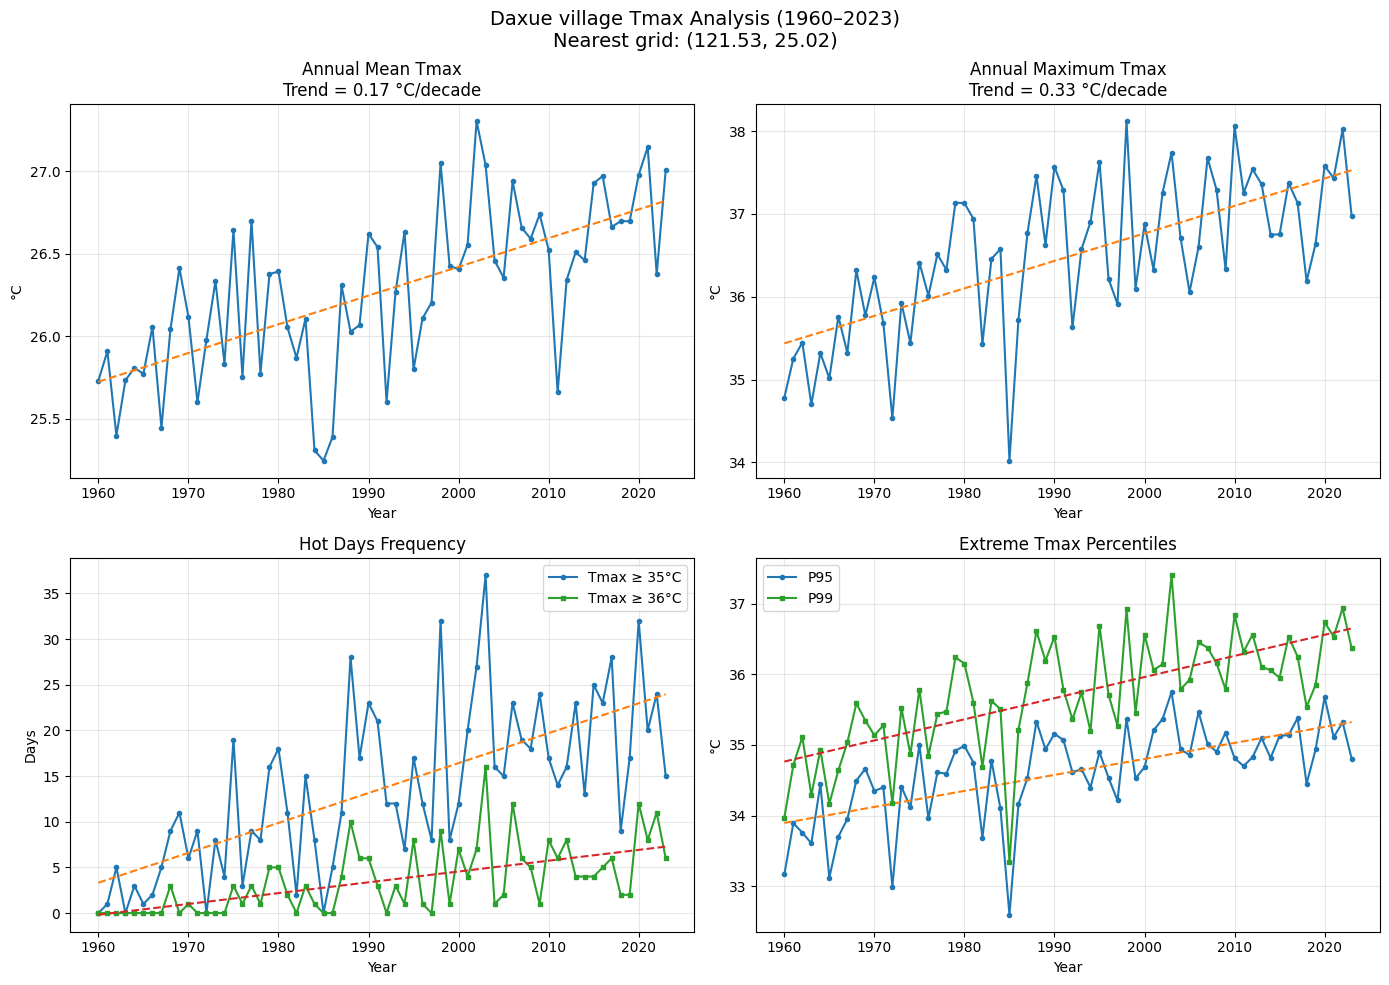

In [10]:
# =========================
# 5. 畫總覽圖（paper/report style）
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Annual mean Tmax
axes[0, 0].plot(years, summary_df["annual_mean_tmax"], linewidth=1.5, marker="o", markersize=3)
axes[0, 0].plot(years, trend_mean, linestyle="--")
axes[0, 0].set_title(f"Annual Mean Tmax\nTrend = {slope_mean*10:.2f} °C/decade")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("°C")
axes[0, 0].grid(alpha=0.3)

# 2. Annual max Tmax
axes[0, 1].plot(years, summary_df["annual_max_tmax"], linewidth=1.5, marker="o", markersize=3)
axes[0, 1].plot(years, trend_amax, linestyle="--")
axes[0, 1].set_title(f"Annual Maximum Tmax\nTrend = {slope_amax*10:.2f} °C/decade")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("°C")
axes[0, 1].grid(alpha=0.3)

# 3. Hot days
axes[1, 0].plot(years, summary_df["hot_days_ge_35"], linewidth=1.5, marker="o", markersize=3, label="Tmax ≥ 35°C")
axes[1, 0].plot(years, trend_hot35, linestyle="--")
axes[1, 0].plot(years, summary_df["hot_days_ge_36"], linewidth=1.5, marker="s", markersize=3, label="Tmax ≥ 36°C")
axes[1, 0].plot(years, trend_hot36, linestyle="--")
axes[1, 0].set_title("Hot Days Frequency")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Days")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. P95 / P99
axes[1, 1].plot(years, summary_df["p95_tmax"], linewidth=1.5, marker="o", markersize=3, label="P95")
axes[1, 1].plot(years, trend_p95, linestyle="--")
axes[1, 1].plot(years, summary_df["p99_tmax"], linewidth=1.5, marker="s", markersize=3, label="P99")
axes[1, 1].plot(years, trend_p99, linestyle="--")
axes[1, 1].set_title("Extreme Tmax Percentiles")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("°C")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle(
    f"Daxue village Tmax Analysis (1960–2023)\nNearest grid: ({nearest_lon:.2f}, {nearest_lat:.2f})",
    fontsize=14
)
plt.tight_layout()
plt.savefig("Daxue＿Tmax Analysis (1960–2023).png", dpi=300)
plt.show()